# Part 2 – Maps
**Group 2 · Season 2023 (January 1 to May 31)**

Part 1 explored the relationship between rainfall and emergency declarations through charts, and showed that the departments with the highest rainfall did not receive the most declarations. Nevertheless, a chart places each department along an axis rather than on the territory, so it cannot show whether this mismatch follows a geographic pattern. The present notebook therefore maps the same table, `tabla_final.csv`, in order to continue addressing the research question. **Does the State declare emergencies where it rains the most?**

To that end, the table is first joined with the department boundaries of Peru, which are stored in `departamentos_peru.geojson`. Since this file identifies each department only by its name, the join requires an intermediate step in which each boundary is assigned its `ubigeo`, followed by a verification that no department was lost along the way. Subsequently, two static choropleth maps built with **Geopandas** compare emergency declarations and rainfall across the country, and an interactive map built with **Folium** allows readers to inspect the values of each department. Finally, the last section discusses what the maps reveal that the charts of Part 1 did not.

In [1]:
import unicodedata

import folium
import geopandas as gpd
import mapclassify
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

fuente = "Source: PCM emergency decrees (gob.pe) and Open-Meteo, Jan-May 2023. Own elaboration."

## 1. Load the data

The analysis starts from `tabla_final.csv`, the table built in Assignment 2 and already used in Part 1, which contains one row per department. As in Part 1, the `ubigeo` column is read as text rather than as a number. This decision is even more important in the present notebook, since the `ubigeo` will serve as the key for joining the table with the map. If it were read as a number, codes such as `01` (Amazonas) would become `1` and would no longer match their two-digit form. In addition, the file is read with the `utf-8-sig` encoding, so that the invisible character at the beginning of the file does not become part of the name of the first column.

The output confirms that the table contains 25 rows, one per department, and 9 columns, and that every `ubigeo` keeps its two digits, starting with `01` for Amazonas.

In [2]:
tabla = pd.read_csv("datos/tabla_final.csv", encoding="utf-8-sig", dtype={"ubigeo": str})

tabla.shape

(25, 9)

In [3]:
print("Digits per ubigeo:", tabla["ubigeo"].str.len().unique())
tabla[["ubigeo", "departamento"]].head(3)

Digits per ubigeo: [2]


,ubigeo,departamento
0,01,Amazonas
1,02,Áncash
2,03,Apurímac


## 2. Load the department boundaries and assign their ubigeo

The boundaries of the 25 departments come from `departamentos_peru.geojson`, a file that stores the shape of each department as a polygon. However, this file contains only two columns, namely the name of the department and its geometry, so it does not include the `ubigeo`. Moreover, its names are written differently from those in `tabla_final.csv`, since they appear in capital letters and without accent marks (for example, `ANCASH` instead of `Áncash`). Consequently, a direct join by name would fail.

In order to solve this problem, the names on both sides were normalized in the same way, that is, converted to capital letters and stripped of their accent marks with the `strip_accents` function from Assignment 2, which relies on the `unicodedata` library. Then, each normalized name in the table was paired with its `ubigeo`, and this pairing was used to assign the corresponding `ubigeo` to each geometry. It should be noted that the names are used only in this step. From this point onwards, the map and the table are joined exclusively through the `ubigeo`, read as text, because a two-digit code cannot be affected by differences in spelling, capitalization or accent marks.

In [4]:
mapa = gpd.read_file("datos/departamentos_peru.geojson")

mapa.shape, list(mapa.columns)

((25, 2), ['departamento', 'geometry'])

In [5]:
def strip_accents(text):
    """Remove accent marks so 'Áncash' becomes 'Ancash' (same as Assignment 2)."""
    decomposed = unicodedata.normalize("NFD", str(text))
    return "".join(c for c in decomposed if unicodedata.category(c) != "Mn")

def normalizar(nombre):
    return strip_accents(nombre).upper()

# Normalized name -> ubigeo, taken from the table
ubigeo_por_nombre = dict(zip(tabla["departamento"].map(normalizar), tabla["ubigeo"]))

# Keep the GeoJSON name apart so it does not collide with the one in the table
mapa = mapa.rename(columns={"departamento": "nombre_geojson"})
mapa["ubigeo"] = mapa["nombre_geojson"].map(normalizar).map(ubigeo_por_nombre)

mapa[["nombre_geojson", "ubigeo"]].head()

,nombre_geojson,ubigeo
0,AMAZONAS,01
1,ANCASH,02
2,APURIMAC,03
3,AREQUIPA,04
4,AYACUCHO,05


## 3. Verification of the join

Before drawing any map, it is necessary to verify that every department in the table found its geometry and that every geometry found its data. This verification is required because a failed join does not produce an error message. Instead, the affected department simply disappears from the map or is drawn without color, which could easily go unnoticed and would distort the comparison. For this reason, two lists were printed, namely the departments of the table without a geometry and the geometries without data, both of which should be empty. Then, the map and the table were joined by `ubigeo`, and the result was checked to contain exactly 25 rows. The option `validate="one_to_one"` additionally ensures that no `ubigeo` appears twice on either side, since a duplicate would multiply the rows.

Furthermore, in order to document which spelling difference had to be resolved, the second cell counts how many names of the table match the GeoJSON at each stage of the normalization, and lists the departments that would have been lost if the names had only been converted to capital letters.

In [6]:
sin_geometria = tabla.loc[~tabla["ubigeo"].isin(mapa["ubigeo"]), "departamento"].tolist()
sin_datos = mapa.loc[~mapa["ubigeo"].isin(tabla["ubigeo"]), "nombre_geojson"].tolist()

print("Departments in the table without geometry:", sin_geometria)
print("Geometries without data:", sin_datos)

mapa_datos = mapa[["ubigeo", "geometry"]].merge(tabla, on="ubigeo", how="inner", validate="one_to_one")
print("Rows after the join:", len(mapa_datos), "(expected: 25)")

if sin_geometria or sin_datos or len(mapa_datos) != 25:
    raise RuntimeError("The join between the map and the table is incomplete.")

Departments in the table without geometry: []
Geometries without data: []
Rows after the join: 25 (expected: 25)


In [7]:
nombres_geojson = set(mapa["nombre_geojson"])
print("Matches as written in the table: ", tabla["departamento"].isin(nombres_geojson).sum())
print("Matches with capital letters only:", tabla["departamento"].str.upper().isin(nombres_geojson).sum())
print("Matches with capitals, no accents:", tabla["departamento"].map(normalizar).isin(nombres_geojson).sum())

tabla.loc[~tabla["departamento"].str.upper().isin(nombres_geojson), ["ubigeo", "departamento"]]

Matches as written in the table:  0
Matches with capital letters only: 20
Matches with capitals, no accents: 25


,ubigeo,departamento
1,02,Áncash
2,03,Apurímac
9,10,Huánuco
11,12,Junín
21,22,San Martín


Both lists are empty and the joined table has 25 rows, so every department of `tabla_final.csv` was matched with its boundary, and vice versa. The second output shows the spelling difference that had to be resolved, which actually consisted of two differences. First, the GeoJSON writes every name in capital letters, so none of the 25 names matched as written in the table. Second, the GeoJSON omits accent marks, which affected five departments, namely Áncash, Apurímac, Huánuco, Junín and San Martín. Accordingly, converting the names to capital letters alone would have matched only 20 departments, and the remaining five would have silently disappeared from the maps. This omission would have been particularly serious, given that Áncash is one of the two departments with the most declarations and San Martín is among the five with the highest rainfall. Only after the accent marks were also removed did all 25 names match.

Finally, it should be noted that removing accent marks also turns the letter `ñ` into `n`, as was pointed out in Assignment 2. Nevertheless, this does not create any problem here, since no department name contains that letter, and in any case the names were only used to assign the `ubigeo`, which is the key used in the rest of the notebook.

## 4. Static maps of emergency declarations and rainfall

In order to compare how emergency declarations and rainfall are distributed across the territory, two choropleth maps were drawn with Geopandas, in which each department is colored according to its value. They were placed side by side, so that the same department can be located in both maps at a glance. In addition, a different color was used for each variable, orange for declarations and blue for rainfall, so that the two maps are not mistaken for one another. Within each map, darker colors represent higher values, and the lightest shade was set slightly darker than white, so that the departments in the lowest class can still be distinguished from the background.

The departments were grouped into five classes using quantiles (`scheme="quantiles"` from mapclassify), so that each class contains approximately the same number of departments. This method was preferred over classes of equal width because rainfall is very unequal across departments, as the histogram of Part 1 showed. With classes of equal width, nine departments would share the same middle class, whereas only Loreto and Ucayali would reach the darkest one. Nevertheless, quantiles also have a limitation, since the colors reflect the position of each department in the ranking rather than the size of the differences between them. For instance, in the declarations map, two consecutive classes may differ by a single declaration. Moreover, because many departments share the same number of declarations, the classes of that map contain between four and six departments rather than exactly five. For this reason, the legend shows the lowest and the highest value actually observed within each class, instead of the cut points calculated by mapclassify.

As the maps show, the two variables follow almost opposite geographic patterns. On the one hand, the darkest blue class, with more than 1,000 mm, is formed by four Amazonian departments, namely Loreto, Ucayali, Madre de Dios and San Martín, together with Áncash, whereas the lightest class, with less than 120 mm, is formed by five coastal departments, namely Lima, Callao, Ica, Moquegua and Tacna. On the other hand, the darkest orange class, with 5 or 6 declarations, is formed by Lima, La Libertad, Áncash and Ayacucho, all located on the coast or in the Andes, whereas Loreto and Madre de Dios, two of the three rainiest departments, fall into the lightest class. It should be noted that Callao is too small to be seen at this scale, although it is included in both maps.

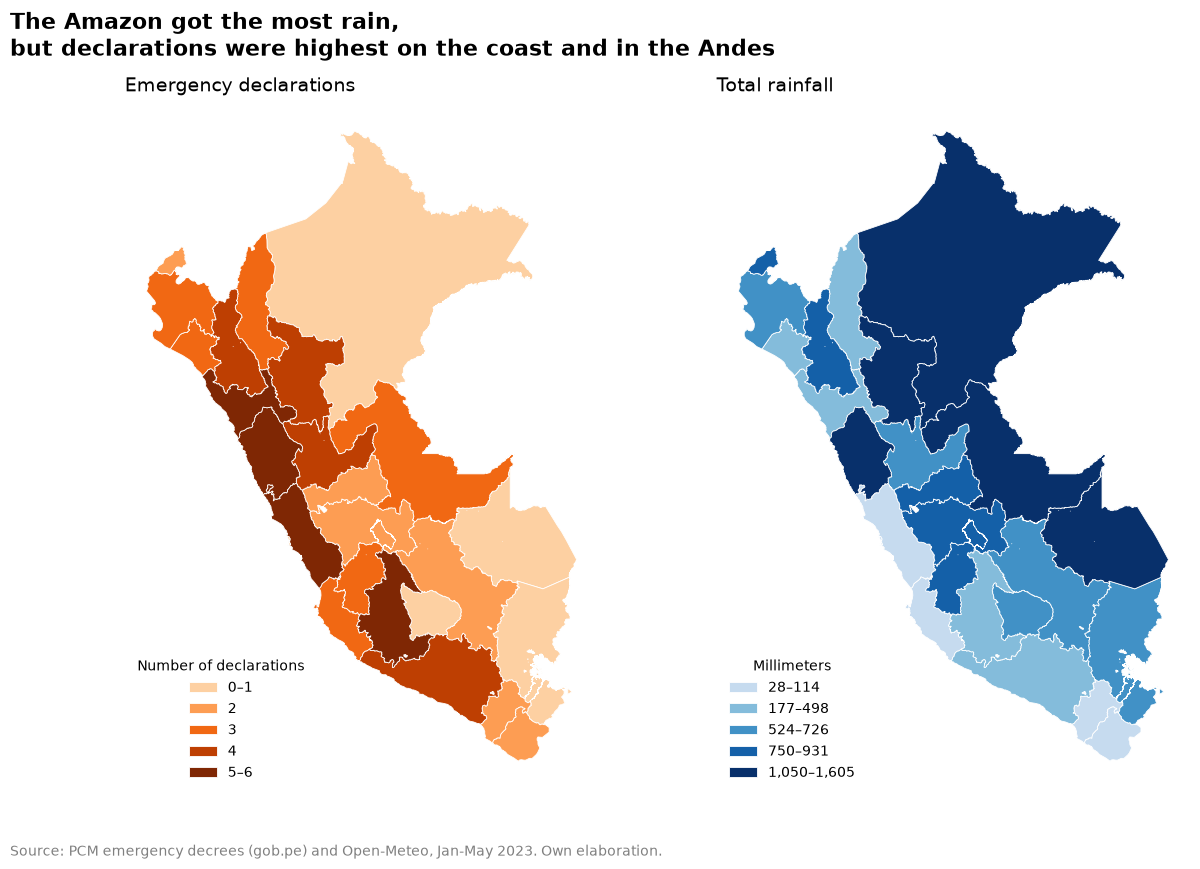

In [8]:
def etiquetas_cuantiles(valores):
    """Legend labels with the lowest and highest value inside each quantile class."""
    clases = mapclassify.Quantiles(valores, k=5)
    etiquetas = []
    for c in range(clases.k):
        grupo = valores[clases.yb == c]
        bajo, alto = f"{grupo.min():,.0f}", f"{grupo.max():,.0f}"
        etiquetas.append(bajo if bajo == alto else f"{bajo}–{alto}")
    return etiquetas

mapas = [("declaratorias", "Oranges", "Emergency declarations", "Number of declarations"),
         ("lluvia_total_mm", "Blues", "Total rainfall", "Millimeters")]

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
for ax, (columna, paleta, titulo, leyenda) in zip(axes, mapas):
    # Same palette without its almost-white end, so the lowest class stays visible
    colores = ListedColormap(plt.get_cmap(paleta)(np.linspace(0.25, 1, 5)))
    mapa_datos.plot(column=columna, scheme="quantiles", k=5, cmap=colores,
                    edgecolor="white", linewidth=0.6, legend=True, ax=ax,
                    legend_kwds={"title": leyenda, "labels": etiquetas_cuantiles(mapa_datos[columna]),
                                 "loc": "lower left", "frameon": False})
    ax.set_title(titulo, loc="left", fontsize=14)
    ax.set_axis_off()

fig.suptitle("The Amazon got the most rain,\nbut declarations were highest on the coast and in the Andes",
             x=0.05, ha="left", fontsize=16, fontweight="bold")
fig.text(0.05, 0.04, fuente, fontsize=10, color="gray")
plt.show()

## 5. Interactive map of rainfall

Although the static maps allow the two variables to be compared at a glance, they do not show the exact value of each department. For this reason, an interactive map was built with Folium, in which departments are colored according to their total rainfall, using the same five quantile classes as the static map. Moreover, when the cursor is placed over a department, a tooltip displays its name, its number of emergency declarations and its total rainfall, so that both variables can be read together for each department, as in the scatter plot of Part 1, but now on the territory. The map can also be zoomed in, which makes it possible to inspect small departments such as Callao, which is barely visible in the static maps.

It should be noted that the colors are assigned by joining the table with the map through the `ubigeo` (`key_on="feature.properties.ubigeo"`), so this step also relies on the code rather than on the department names. As an example of what the tooltip reveals, hovering over Loreto shows the highest rainfall in the country, 1,604.6 mm, but only one declaration, whereas Lima, with only 55.5 mm, received six.

In [ ]:
cortes = mapa_datos["lluvia_total_mm"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1]).tolist()

# Fixed-size figure, so the map is displayed without Folium's "Trust Notebook" placeholder
figura = folium.Figure(width="100%", height=550)
mapa_interactivo = folium.Map(location=[-9.2, -75], zoom_start=5, tiles="Esri.WorldGrayCanvas")
mapa_interactivo.add_to(figura)

coropleta = folium.Choropleth(
    geo_data=mapa_datos,
    data=tabla,
    columns=["ubigeo", "lluvia_total_mm"],
    key_on="feature.properties.ubigeo",
    bins=cortes,
    fill_color="Blues",
    fill_opacity=0.8,
    line_color="white",
    line_weight=1,
    highlight=True,
    legend_name="Total rainfall, January to May 2023 (mm)",
).add_to(mapa_interactivo)

folium.GeoJsonTooltip(
    fields=["departamento", "declaratorias", "lluvia_total_mm"],
    aliases=["Department:", "Emergency declarations:", "Total rainfall (mm):"],
    localize=True,
).add_to(coropleta.geojson)

# Title and source note on top of the map
titulo = "The three rainiest departments, all in the Amazon, received three declarations or fewer"
mapa_interactivo.get_root().html.add_child(folium.Element(f"""
<div style="position: fixed; bottom: 34px; left: 10px; z-index: 1000; max-width: 280px;
            background: white; padding: 6px 10px; font: bold 14px Arial;">{titulo}</div>
<div style="position: fixed; bottom: 8px; left: 10px; z-index: 1000;
            background: white; padding: 2px 6px; font: 11px Arial; color: gray;">{fuente}</div>
"""))

mapa_interactivo.save("mapa.html")
mapa_interactivo

## 6. Conclusion. The gap between rainfall and declarations follows a regional pattern

The maps answer the research question in the same direction as Part 1, namely that the State did not declare emergencies where it rained the most. Nevertheless, they add a geographic dimension that the charts could not offer, since they show that the gap between rainfall and declarations is not scattered randomly across the country, but follows a regional pattern.

First, the departments with the most rain and the fewest declarations form a continuous block in the east of the country. In Part 1, Loreto, Ucayali and Madre de Dios appeared as separate points on the right side of the scatter plot, with the highest rainfall but between 0 and 3 declarations. The maps reveal that these three departments are neighbors, that together they cover the Amazonian lowlands along the borders with Ecuador, Colombia, Brazil and Bolivia, and that they occupy a large share of the national territory. Conversely, the departments with little rain and many declarations, such as Lima, Ica and La Libertad, are located on the Pacific coast, and the darkest classes of the declarations map are concentrated on the coast and in the Andes. Therefore, the mismatch can be described in terms of regions, the Amazon on one side and the coast on the other, rather than as a list of individual departments.

Second, the maps reveal differences within these regions that the charts concealed. In the histogram of Part 1, the coastal departments appeared together among the driest, but the rainfall map shows that the coast was not uniformly dry. While Lima, Callao, Ica, Moquegua and Tacna recorded less than 120 mm, Tumbes and Piura, on the northern coast, recorded 931 and 719 mm, respectively, which places them in the rainier half of the country. This contrast between the northern and the southern coast only becomes visible once the departments are placed on the territory.

Finally, the maps also introduce limitations that should be kept in mind. On the one hand, a choropleth gives more visual weight to large departments, so the Amazonian departments, which are extensive but sparsely populated, dominate the image, whereas Lima and Callao, which concentrate a large part of the population of the country, occupy a small area. Therefore, the maps may make the mismatch look larger than it is in terms of the number of people affected. On the other hand, as explained in Part 1, the rainfall of each department was measured at a single point, its capital. On a map, this limitation becomes more visible, since the color extends the value of the capital to the entire department. For example, Áncash appears among the rainiest departments because of the rainfall recorded in Huaraz, in the Andes, even though the department also includes a stretch of the arid coast. Consequently, the maps should be read as a comparison between departments, and not as a precise picture of where it rained within each of them.